# Predicting Fourth Down Conversions in the NFL
Connor Quadrini

---
embed-resources: true
echo: false
---

## Introduction

This report/project outlines a predictive model designed to estimate fourth down conversion probabilities, providing the offensive coordinator with a data-driven tool for play calling. By analyzing historical outcomes based on distance, field position, and play type, my goal is to supply the success estimates necessary for maximizing win probability in high stakes situations. I will be utilizing a Histogram Gradient Boosting Classifier, which excels at capturing the non-linear relationships between game variables and successful execution, and the data used is from 2019-2025 in the NFL.

## Methods

In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve


### Data

In [2]:
# load data
football = pd.read_parquet(
    "https://lab.cs307.org/football/data/football.parquet",
)
cutoff_date = pd.Timestamp('2024-08-01')
train = football[football['game_date'] < cutoff_date]
test = football[football['game_date'] >= cutoff_date]

Target variable:
converted ~ [object] result of fourth-down conversion attempt. One of No or Yes.

Features:
togo ~ [float64] distance in yards from either the first down marker or the end zone in goal down situations. Distance needed to successfully convert the fourth-down attempt.
yardline ~ [float64] distance in yards from the opponent’s end zone. Distance needed to score a touchdown.
play_type ~ [object] type of play. One of Pass or Run. Pass plays include sacks. Run plays include scrambles.
posteam ~ [object] the abbreviation for the team with possession of the ball.
defteam ~ [object] the abbreviation for the team on defense.

In [23]:
# summary statistics
print('The test data makes up',format(len(test)/len(football),'.2%'),'of the original data')

The test data makes up 17.92% of the original data


In [4]:
train.describe() #converted_success made yes and no into integers to calculate the train conversion rate

,game_date,togo,yardline
count,3737,3737.000000,3737.000000
mean,2022-01-01 17:48:32.175541760,4.152796,37.662296
min,2019-09-05 00:00:00,1.000000,1.000000
25%,2020-11-08 00:00:00,1.000000,21.000000
50%,2021-12-12 00:00:00,2.000000,38.000000
75%,2023-01-01 00:00:00,5.000000,53.000000
max,2024-02-11 00:00:00,34.000000,99.000000
std,NaN,4.613248,22.000206


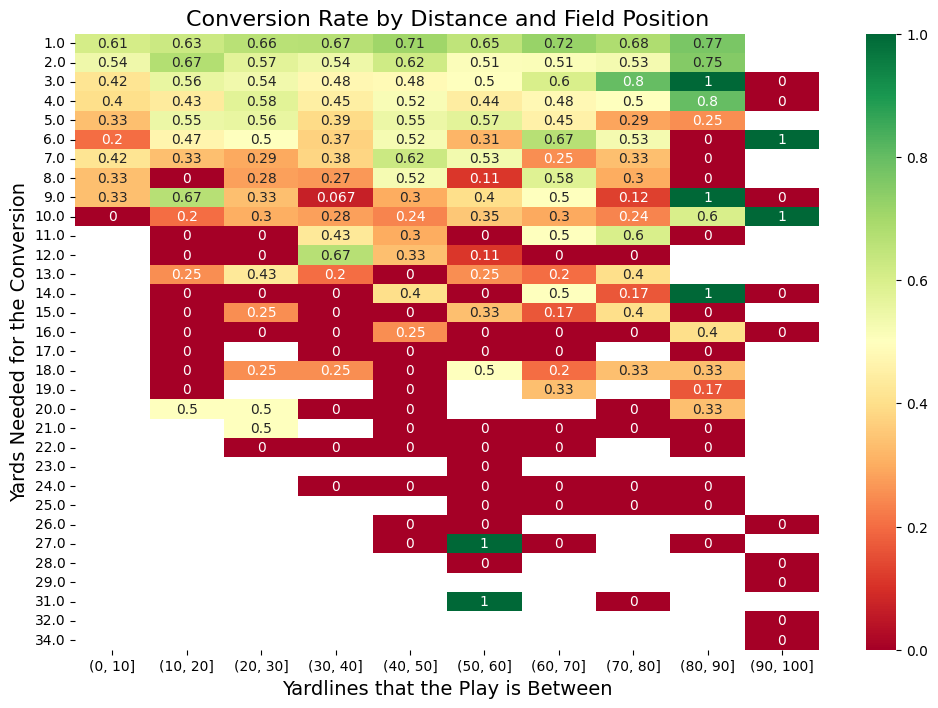

In [28]:
# exploratory visualization
train['converted_success'] = (train['converted'] == 'Yes').astype(int)
train['yardline_bin'] = pd.cut(train['yardline'], bins=range(0, 101, 10))

pivot_table = train.pivot_table(
    index='togo', 
    columns='yardline_bin', 
    values='converted_success',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap="RdYlGn")
plt.title("Conversion Rate by Distance and Field Position",fontsize=16)
plt.ylabel("Yards Needed for the Conversion",fontsize=14)
plt.xlabel("Yardlines that the Play is Between",fontsize=14)
plt.show()

### Models

In [6]:
# process data for ML
# create X and y for train
X_train = train.drop("converted", axis=1)
y_train = train["converted"]

# create X and y for test
X_test = test.drop("converted", axis=1)
y_test = test["converted"]

In [7]:
# train models
train['target'] = train['converted'].map({'Yes': 1, 'No': 0}) # the same as train['converted_success']
y_test_numeric = y_test.map({'Yes': 1, 'No': 0})

features = ['togo', 'yardline', 'play_type']
X_train = train[features].copy()
X_test = test[features].copy()

encoder = OrdinalEncoder()
X_train['play_type'] = encoder.fit_transform(X_train[['play_type']])
X_test['play_type'] = encoder.transform(X_test[['play_type']])

param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'l2_regularization': [0.0, 0.1, 1.0]
}

# Used RandomizedSearchCV to find the best parameters efficiently
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(categorical_features=[2], random_state=42),
    param_distributions,
    n_iter=10,
    scoring='neg_log_loss',
    cv=5,
    random_state=42
)
search.fit(X_train, train['target'])
best_base_model = search.best_estimator_

calibrated_model = CalibratedClassifierCV(
    best_base_model, 
    method='isotonic', 
    cv=5
)

calibrated_model.fit(X_train, train['target'])

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",HistGradientB...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Inte

In [25]:
# Returns the success probability for the Offensive Coordinator -- play_type should be 'Pass' or 'Run'.
def get_conversion_probability(togo, yardline, play_type):
# Put input into the format that the model expects
    input_data = pd.DataFrame([[togo, yardline, play_type]], columns=['togo', 'yardline', 'play_type'])
    input_data['play_type'] = encoder.transform(input_data[['play_type']])
    # Get the probability
    prob = calibrated_model.predict_proba(input_data)[:, 1][0]
    return format(prob, ".1%")

print('Example: 4th and 5 on the 20-yard line')
print("Success Probability (Run):", get_conversion_probability(5, 20, 'Run'))
print("Success Probability (Pass):", get_conversion_probability(5, 20, 'Pass'))

Example: 4th and 5 on the 20-yard line
Success Probability (Run): 57.7%
Success Probability (Pass): 47.6%


To build this fourth down success estimator, I used a Histogram-Based Gradient Boosting Classifier, an approach that excels at identifying complex relationships in situational football data. The process began by encoding situational variables (distance to go and field position) into a format that allows the model to recognize unique patterns, such as the drastically different success rates found near the goal line. Instead of treating every yard equally, the model uses a binning technique to group data, which significantly increases the speed of calculation and reduces the impact of outliers in the historical records. To ensure the model provides a reliable success percentage rather than just a simple "Yes or No" guess, I performed hyperparameter tuning and Isotonic Calibration, which aligns the model's predictions with historical patterns. Ultimately, this creates a calibrated forecast that allows the coaching staff to weigh situational risks with precision.

## Results

In [9]:
# report model metrics
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

brier = brier_score_loss(y_test_numeric, y_prob)
loss = log_loss(y_test_numeric, y_prob)
print('Brier score:', brier,' Log loss:', loss)

Brier score: 0.21926365039794996  Log loss: 0.6283575669124952


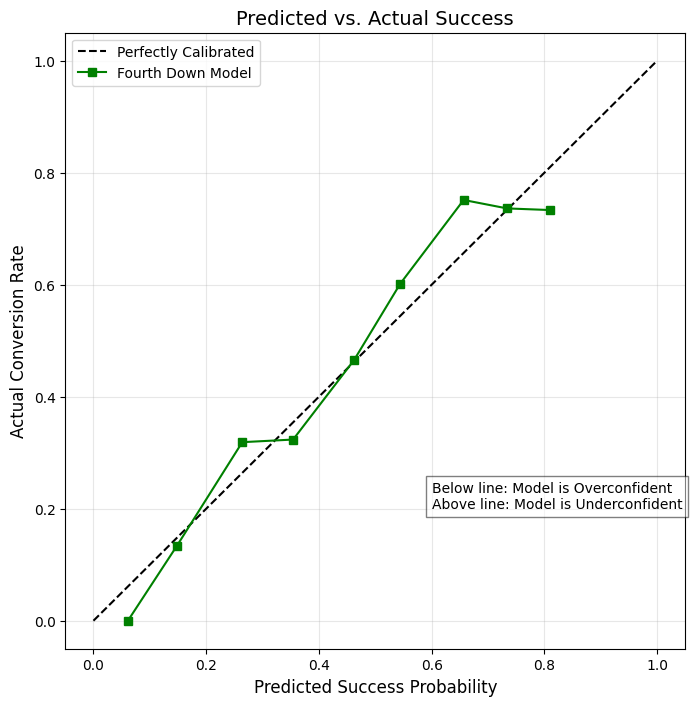

In [10]:
# summary figure

# prob_true is the actual success rate in each bin
# prob_pred is the average predicted probability in each bin
prob_true, prob_pred = calibration_curve(y_test_numeric, y_prob, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, prob_true, "s-", label="Fourth Down Model", color='green')

plt.ylabel("Actual Conversion Rate", fontsize=12)
plt.xlabel("Predicted Success Probability", fontsize=12)
plt.title("Predicted vs. Actual Success", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

plt.text(0.6, 0.2, "Below line: Model is Overconfident\nAbove line: Model is Underconfident", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()

## Discussion

I would definitely choose to put this model into practice as the offensive coordinator's decision making tool. The main benefit is that personal intuition gets replaced with a calibrated success probability, providing a data driven baseline for the decision to attempt a fourth down conversion. By achieving a brier score of 0.219, the model demonstrates an ability to accurately account for the complex, non-linear relationships between field position and yardage. In addition, the log loss of 0.628 indicates that the model provides more informative and reliable success probabilities than a simple league average, making sure that the offensive coordinator isn't misled by "overconfident" but incorrect predictions. In contrast, a significant limitation is that the model currently lacks context like real-time weather conditions, crowd noise, and time left in the game. Thus, these estimates should be viewed as a strategic base that requires human oversight to adjust for  conditions like the ones just mentioned or specific defensive matchups on the field. Overall, this model provides mathematically rigorous predictions that significantly enhance situational efficiency and can be used to optimize the team’s win probability.